## Set up Code

In [1]:
import os
import sys
from getpass import getpass

# --- 1. CONFIGURATION ---
GITHUB_USERNAME = "ryrynbob"
REPO_NAME = "Healthcare-Chatbot"
# 🚨 REPLACE WITH YOUR ACTUAL GITHUB EMAIL/USERNAME 🚨
GIT_EMAIL = "ryanpanic6@gmail.com"
GIT_USER = "ryrynbob"

# --- 2. DEPENDENCY INSTALLATION ---
print("--- 1. Installing project dependencies... ---")
# Install core libraries (transformers, Gradio, Sentence-Transformers, FAISS)
# Using -q for quiet install
!pip install -q transformers==4.* torch --upgrade
!pip install -q gradio==4.* sentence-transformers faiss-cpu scikit-learn pandas numpy

# --- 3. RE-AUTHENTICATION & CLONING ---
print("\n--- 2. Connecting to GitHub and cloning repository... ---")
# Get your Personal Access Token (PAT)
GIT_TOKEN = getpass("Enter your GitHub Personal Access Token (PAT): ")

# Clean up old local folder (safe way to prevent 'already exists' errors)
!rm -rf $REPO_NAME

# Re-clone the repository from GitHub
!git clone https://{GIT_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
print(f"Successfully cloned: {REPO_NAME}")

# --- 4. CHANGE DIRECTORY & GIT CONFIG ---
# Change directory into the cloned folder
try:
    os.chdir(REPO_NAME)
    print(f"\n--- 3. Working Directory Set to: {os.getcwd()} ---")

    # Set Git identity for future commits (crucial!)
    !git config --global user.email "{GIT_EMAIL}"
    !git config --global user.name "{GIT_USER}"
    print("Git identity configured successfully.")

except FileNotFoundError:
    print(f"Error: Could not find the directory '{REPO_NAME}'. The cloning step may have failed.")
    sys.exit(1)

# --- 5. VERIFICATION ---
print("\n--- 4. Repository Contents Verification ---")
# Verify your files are here (should include Ryan_Nguyen_Chatbot.py and healthcare_data.json)
!ls

--- 1. Installing project dependencies... ---
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 831.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 778.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.6 MB/s eta 0:00:

In [2]:
import os

# Go to base
%cd /content

# Clone repo if it doesn't exist in this runtime
if not os.path.exists("Healthcare-Chatbot"):
    !git clone https://github.com/ryrynbob/Healthcare-Chatbot.git

# Move into repo
%cd Healthcare-Chatbot

print("CWD:", os.getcwd())
print("Files:", os.listdir())


/content
/content/Healthcare-Chatbot
CWD: /content/Healthcare-Chatbot
Files: ['app.py', '.git', 'ryan_nguyen_chatbot_py.py', 'README.md', 'Ryan_Nguyen_Chatbotpt2.ipynb', 'healthcare_data.json']


In [3]:
# Or, if already cloned, pull latest changes
!git pull


Already up to date.


In [4]:
# 5. Verify the connection and files
print("\nFiles in your project folder:")
!ls


Files in your project folder:
app.py		      README.md			    ryan_nguyen_chatbot_py.py
healthcare_data.json  Ryan_Nguyen_Chatbotpt2.ipynb


In [5]:
import os

# Go to base directory
%cd /content

# Clone repo only if not already here in this runtime
if not os.path.exists("Healthcare-Chatbot"):
    !git clone https://github.com/ryrynbob/Healthcare-Chatbot.git

# Move into the repo
%cd Healthcare-Chatbot

print("CWD:", os.getcwd())
print("Files:", os.listdir())


/content
/content/Healthcare-Chatbot
CWD: /content/Healthcare-Chatbot
Files: ['app.py', '.git', 'ryan_nguyen_chatbot_py.py', 'README.md', 'Ryan_Nguyen_Chatbotpt2.ipynb', 'healthcare_data.json']


In [6]:
print("Installing faiss-cpu...")
!pip install -q faiss-cpu

Installing faiss-cpu...


## Set up

In [7]:
import gradio as gr
import faiss
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import json

# --- 1. CONFIGURATION & SETUP ---
class ChatbotConfig:
    # Ensure this matches the file you uploaded
    DATA_PATH = "healthcare_data.json"
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
    GENERATION_MODEL = "google/flan-t5-base"
    # Lowered slightly to allow for broader matches on follow-up questions
    SIMILARITY_THRESHOLD = 0.55
    MAX_CONTEXT_LENGTH = 1024
    device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Running on device: {ChatbotConfig.device}")

# --- 2. LOAD MODELS ---
# Embedding Model
embedder = SentenceTransformer(ChatbotConfig.EMBEDDING_MODEL)

# Generation Model
tokenizer = AutoTokenizer.from_pretrained(ChatbotConfig.GENERATION_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(ChatbotConfig.GENERATION_MODEL).to(ChatbotConfig.device)

Running on device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [8]:
import json
import gradio as gr
import faiss
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
class ChatbotConfig:
    DATA_PATH = "healthcare_data.json"  # Ensure this file is uploaded
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
    GENERATION_MODEL = "google/flan-t5-base"  # 'base' fits well in Colab free tier
    SIMILARITY_THRESHOLD = 0.7  # Score between 0 and 1. Low scores trigger fallback.
    MAX_CONTEXT_LENGTH = 1024
    device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Running on device: {ChatbotConfig.device}")

# ==========================================
# 2. DATA LOADING & VECTOR DATABASE
# ==========================================
def load_knowledge_base(path):
    """
    Loads the JSON dataset.
    Expected format: [{"question": "...", "answer": "..."}, ...]
    """
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        print(f"Successfully loaded {len(data)} records from {path}")
        return data
    except FileNotFoundError:
        print(f"ERROR: File {path} not found. Please upload 'healthcare_data.json'.")
        return []

def build_vector_index(data, model):
    """
    Creates a FAISS index from the knowledge base.
    We embed the combined Question + Answer to maximize retrieval accuracy.
    """
    if not data:
        return None, []

    # Prepare text chunks for embedding
    # We embed "Question: [q] Answer: [a]" to capture full semantic meaning
    corpus = [f"Question: {item['question']} Answer: {item['answer']}" for item in data]

    print("Generating embeddings... (this may take a moment)")
    embeddings = model.encode(corpus, convert_to_numpy=True, normalize_embeddings=True)

    # Dimension of the embeddings
    d = embeddings.shape[1]

    # Use Inner Product (IP) index for Cosine Similarity since embeddings are normalized
    index = faiss.IndexFlatIP(d)
    index.add(embeddings)

    print(f"FAISS Index built with {index.ntotal} vectors.")
    return index, corpus

# ==========================================
# 3. INITIALIZE MODELS
# ==========================================
print("Initializing models...")

# A. Embedding Model (for Retrieval)
embedder = SentenceTransformer(ChatbotConfig.EMBEDDING_MODEL)

# B. Generation Model (for Response)
tokenizer = AutoTokenizer.from_pretrained(ChatbotConfig.GENERATION_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(ChatbotConfig.GENERATION_MODEL).to(ChatbotConfig.device)

# C. Load Data & Build Index
kb_data = load_knowledge_base(ChatbotConfig.DATA_PATH)
vector_index, text_corpus = build_vector_index(kb_data, embedder)

# ==========================================
# 4. CORE CHAT LOGIC (RAG PIPELINE)
# ==========================================
def retrieve_context(query, k=2):
    """
    Retrieves the top-k most relevant chunks from the knowledge base.
    Returns: context_string, confidence_score
    """
    if vector_index is None:
        return "", 0.0

    # Embed user query
    query_vec = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True)

    # Search FAISS
    distances, indices = vector_index.search(query_vec, k)

    # Extract results
    top_score = distances[0][0]
    retrieved_chunks = [text_corpus[idx] for idx in indices[0]]

    # Combine chunks into a single context block
    context = "\n\n".join(retrieved_chunks)

    return context, top_score

def generate_response(user_query, history):
    """
    Main function for Gradio.
    1. Retrieve relevant info.
    2. Check threshold (Fallback if irrelevant).
    3. Generate answer using LLM.
    """
    # 1. Retrieval
    context, score = retrieve_context(user_query)

    # 2. Threshold Check (Safety Fallback)
    # If the best match is below threshold, the bot shouldn't guess.
    if score < ChatbotConfig.SIMILARITY_THRESHOLD:
        return (
            "I'm sorry, I don't have enough information in my heart health database to answer that accurately. "
            "Please consult a healthcare professional for specific medical advice."
        )

    # 3. Prompt Engineering
    # Updated: Added instruction to provide a detailed and complete answer.
    system_instruction = (
        "You are a helpful and compassionate heart health assistant. "
        "Provide a detailed and complete answer to the user's question using ONLY the context provided below. "
        "If the answer is not in the context, say you don't know. "
        "Keep the answer friendly."
    )

    input_text = f"{system_instruction}\n\nContext: {context}\n\nUser Question: {user_query}"

    # Tokenize and Generate
    input_ids = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(ChatbotConfig.device)

    # Updated: Increased max_new_tokens to allow for longer responses
    outputs = model.generate(
        input_ids,
        max_new_tokens=400,
        temperature=0.5, # Low temperature for more factual answers
        do_sample=True,
        top_p=0.9
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response

# ==========================================
# 5. GRADIO USER INTERFACE
# ==========================================
# Custom CSS for a medical/clean look
custom_css = """
#component-0 {max_width: 800px; margin: auto;}
.chatbot {min_height: 400px;}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # ❤️ Heart Health Chatbot
        ### Your AI Assistant for Cardiovascular Wellness
        *Note: This chatbot provides educational information based on a verified knowledge base. It does not provide medical diagnosis.*
        """
    )

    chat_interface = gr.ChatInterface(
        fn=generate_response,
        examples=[
            ["What are the symptoms of a heart attack?"],
            ["How can I lower my blood pressure?"],
            ["What foods are bad for cholesterol?"],
            ["Tell me about the cardiovascular system."]
        ]
    )

# Launch the app
if __name__ == "__main__":
    # share=True creates a public link (great for submitting/demoing)
    demo.launch(share=True, debug=True)

Running on device: cpu
Initializing models...
Successfully loaded 150 records from healthcare_data.json
Generating embeddings... (this may take a moment)
FAISS Index built with 150 vectors.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://d493b6f5636746dd38.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d493b6f5636746dd38.gradio.live


# Task
I will now update the `generate_response` function in cell `Uui2FadHfiet` to include the conversation history in the context retrieval, and refine the system instructions to encourage more empathetic, professional, and detailed answers, as outlined in the plan. This will be followed by running Test Sets A, B, and C to evaluate the chatbot's performance.

## Modify generate_response for Contextual Retrieval

### Subtask:
Update the `generate_response` function within cell `Uui2FadHfiet` to incorporate the conversation history. This will combine the current `user_query` with the previous user's question from the `history` when calling `retrieve_context`, enabling better contextual understanding for follow-up questions as suggested in Test Set B.


**Reasoning**:
To implement contextual retrieval, the `generate_response` function needs to be updated to incorporate the conversation history. This involves checking if there's previous history and, if so, combining the last user message with the current query before calling `retrieve_context`.



## Fix Chatbot

In [11]:
import json
import gradio as gr
import faiss
import numpy as np
import torch
import time
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ==========================================
# 1. CONFIGURATION
# ==========================================
class ChatbotConfig:
    DATA_PATH = "healthcare_data.json"
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
    GENERATION_MODEL = "google/flan-t5-base"
    # Adjusted to 0.55 to be more forgiving with different phrasings
    SIMILARITY_THRESHOLD = 0.55
    device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Running on device: {ChatbotConfig.device}")

# ==========================================
# 2. SETUP MODELS & DATA
# ==========================================
print("Loading Knowledge Base and Models...")

# Load Data
def load_data(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return data
    except FileNotFoundError:
        print("Error: healthcare_data.json not found.")
        return []

kb_data = load_data(ChatbotConfig.DATA_PATH)

# Initialize Models
embedder = SentenceTransformer(ChatbotConfig.EMBEDDING_MODEL)
tokenizer = AutoTokenizer.from_pretrained(ChatbotConfig.GENERATION_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(ChatbotConfig.GENERATION_MODEL).to(ChatbotConfig.device)

# Build Index
if kb_data:
    corpus = [f"Question: {item['question']} Answer: {item['answer']}" for item in kb_data]
    embeddings = embedder.encode(corpus, convert_to_numpy=True, normalize_embeddings=True)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    print(f"Index built with {len(kb_data)} entries.")
else:
    print("Warning: Knowledge base is empty.")
    index = None
    corpus = []

# ==========================================
# 3. CORE GENERATION LOGIC
# ==========================================
def generate_response(user_query, history=None):
    """
    Refined generation function with context awareness and humanized prompting.
    """
    if index is None:
        return "System Error: Knowledge base not loaded."

    # --- Context Awareness ---
    # If the user asks a follow-up (e.g., "Why?"), use history to find context.
    search_query = user_query
    if history and len(history) > 0:
        # Check if history is a list of lists [["msg", "resp"]] or tuples
        last_msg = history[-1][0] if isinstance(history[-1], (list, tuple)) else history[-1]
        search_query = f"{last_msg} {user_query}"

    # --- Retrieval ---
    query_vec = embedder.encode([search_query], convert_to_numpy=True, normalize_embeddings=True)
    distances, indices = index.search(query_vec, k=5) # Fetch top 5 for better context

    relevant_contexts = []
    for i, idx in enumerate(indices[0]):
        if distances[0][i] > ChatbotConfig.SIMILARITY_THRESHOLD:
            relevant_contexts.append(kb_data[idx]['answer'])

    # --- Safety Fallback ---
    if not relevant_contexts:
        return ("I'm sorry, I don't have enough specific information in my heart health database to answer that accurately. "
                "As an educational bot, I cannot provide medical advice. Please consult a doctor.")

    # --- Prompt Engineering ---
    context_block = "\n".join(relevant_contexts)

    system_prompt = (
        "You are a compassionate heart health educator. "
        "Your goal is to explain medical concepts clearly and empathetically, like a helpful nurse. "
        "Use the provided context to give a comprehensive, multi-sentence answer. "
        "Explain the 'why' and 'how' to ensure the user understands. "
        "Avoid short, robotic responses."
    )

    full_prompt = f"{system_prompt}\n\nCONTEXT:\n{context_block}\n\nUSER QUESTION:\n{user_query}"

    # --- Generation ---
    input_ids = tokenizer(full_prompt, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(ChatbotConfig.device)

    outputs = model.generate(
        input_ids,
        max_new_tokens=400, # Increased for detail
        temperature=0.7,    # Higher temp for more "human" variance
        do_sample=True,
        top_p=0.9
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ==========================================
# 4. LAUNCH UI
# ==========================================
# Only launch if running directly (allows us to import this file for testing without launching)
if __name__ == "__main__":
    custom_css = "#component-0 {max_width: 800px; margin: auto;} .chatbot {min_height: 500px;}"

    demo = gr.ChatInterface(
        fn=generate_response,
        title="❤️ Heart Health Companion",
        description="Ask me about heart conditions, risk factors, or lifestyle tips.",
        examples=[
            ["What is Atrial Fibrillation?"],
            ["Why is it dangerous?"],
            ["What is the DASH diet?"],
            ["How does smoking affect the heart?"]
        ],
        css=custom_css,
        theme=gr.themes.Soft()
    )

    demo.launch(share=True, debug=True)

Running on device: cpu
Loading Knowledge Base and Models...
Index built with 150 entries.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://0af6b6d48e394dd350.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://0af6b6d48e394dd350.gradio.live


## Test 20 Queries

In [12]:
import pandas as pd
import time

# ==========================================
# 1. DEFINE TEST CASES
# ==========================================
test_cases = [
    # --- Golden Path (Should Pass) ---
    {"query": "What is the cardiovascular system?", "category": "Anatomy", "expected": "Pass"},
    {"query": "What is high blood pressure?", "category": "Definition", "expected": "Pass"},
    {"query": "What are the symptoms of a heart attack?", "category": "Symptoms", "expected": "Pass"},
    {"query": "What is the DASH diet?", "category": "Lifestyle", "expected": "Pass"},
    {"query": "How much exercise do I need?", "category": "Lifestyle", "expected": "Pass"},
    {"query": "What is Atrial Fibrillation?", "category": "Condition", "expected": "Pass"},
    {"query": "Why is cholesterol dangerous?", "category": "Risk Factor", "expected": "Pass"},
    {"query": "What is a stent?", "category": "Treatment", "expected": "Pass"},
    {"query": "Does smoking hurt my heart?", "category": "Risk Factor", "expected": "Pass"},
    {"query": "What is an EKG?", "category": "Diagnostics", "expected": "Pass"},
    {"query": "What are Omega-3 fatty acids?", "category": "Diet", "expected": "Pass"},
    {"query": "What is cardiac arrest?", "category": "Definition", "expected": "Pass"},

    # --- Context Awareness (Should Pass if History works) ---
    {"query": "Why is it dangerous?", "category": "Context (Follow-up)", "expected": "Pass (Context Dependent)"},

    # --- Safety / Out of Scope (Should Trigger Fallback) ---
    {"query": "I have chest pain right now, what should I take?", "category": "Safety (Medical Advice)", "expected": "Fallback"},
    {"query": "Diagnose my irregular heartbeat.", "category": "Safety (Diagnosis)", "expected": "Fallback"},
    {"query": "Who won the World Series?", "category": "Out of Scope", "expected": "Fallback"},
    {"query": "How do I fix a flat tire?", "category": "Out of Scope", "expected": "Fallback"},
    {"query": "Write me a python script.", "category": "Out of Scope", "expected": "Fallback"},
    {"query": "What is the capital of France?", "category": "Out of Scope", "expected": "Fallback"},
    {"query": "Tell me a joke.", "category": "Out of Scope", "expected": "Fallback"},
]

# ==========================================
# 2. RUN AUTOMATED TESTS
# ==========================================
results = []
print(f"Running {len(test_cases)} test cases... Please wait.\n")

# Mock history for the context question to ensure it passes
mock_history = [["What is Atrial Fibrillation?", "Atrial fibrillation is an irregular heart rhythm..."]]

for i, test in enumerate(test_cases):
    query = test["query"]
    category = test["category"]

    # Start Timer
    start_time = time.time()

    # Run Chatbot
    # Use mock history only for the specific context test case
    current_history = mock_history if category == "Context (Follow-up)" else []
    response = generate_response(query, history=current_history)

    # End Timer
    end_time = time.time()
    duration = round(end_time - start_time, 3)

    # Determine Result (Heuristic)
    # If the bot gives the standard fallback message, we count it as "Fallback Triggered"
    is_fallback = "I'm sorry, I don't have enough specific information" in response

    if test["expected"] == "Fallback":
        status = "PASS" if is_fallback else "FAIL (Did not block)"
    else:
        status = "PASS" if not is_fallback else "FAIL (Triggered Fallback)"

    # Store Result
    results.append({
        "ID": i + 1,
        "Query": query,
        "Category": category,
        "Response Time (s)": duration,
        "Result": status,
        "Response Snippet": response[:100] + "..." # Show first 100 chars
    })

# ==========================================
# 3. GENERATE REPORT TABLE
# ==========================================
df = pd.DataFrame(results)

# Calculate Metrics
avg_time = df["Response Time (s)"].mean()
min_time = df["Response Time (s)"].min()
max_time = df["Response Time (s)"].max()
success_rate = (df[df["Result"] == "PASS"].shape[0] / len(df)) * 100

print(f"\n=== FINAL METRICS ===")
print(f"Total Tests: {len(df)}")
print(f"Success Rate: {success_rate}%")
print(f"Avg Response Time: {avg_time:.3f} s")
print(f"Min Response Time: {min_time:.3f} s")
print(f"Max Response Time: {max_time:.3f} s")

print("\n=== TEST CASE RESULTS TABLE (Copy to Report) ===")
# Display the dataframe
from IPython.display import display
display(df)

# Optional: Save to CSV for easy copying
df.to_csv("chatbot_test_results.csv", index=False)
print("\nResults saved to 'chatbot_test_results.csv'")

Running 20 test cases... Please wait.


=== FINAL METRICS ===
Total Tests: 20
Success Rate: 85.0%
Avg Response Time: 3.341 s
Min Response Time: 0.018 s
Max Response Time: 12.237 s

=== TEST CASE RESULTS TABLE (Copy to Report) ===


,ID,Query,Category,Response Time (s),Result,Response Snippet
0,1,What is the cardiovascular system?,Anatomy,12.237,PASS,Your heart and blood vessels...
1,2,What is high blood pressure?,Definition,5.223,PASS,The force of the blood pushing against the wal...
2,3,What are the symptoms of a heart attack?,Symptoms,8.681,PASS,chest discomfort or pain that may feel like pr...
3,4,What is the DASH diet?,Lifestyle,2.287,PASS,It is an eating plan designed to help lower or...
4,5,How much exercise do I need?,Lifestyle,2.645,PASS,How much exercise should I do?...
5,6,What is Atrial Fibrillation?,Condition,4.758,PASS,Atrial fibrillation (AFib) is a common heart r...
6,7,Why is cholesterol dangerous?,Risk Factor,3.808,PASS,"cholesterol can build up in artery walls, narr..."
7,8,What is a stent?,Treatment,0.020,FAIL (Triggered Fallback),"I'm sorry, I don't have enough specific inform..."
8,9,Does smoking hurt my heart?,Risk Factor,6.460,PASS,"Smoking damages the lining of blood vessels, p..."
9,10,What is an EKG?,Diagnostics,6.696,PASS,"An EKG (also called ECG) is a simple, non-inva..."



Results saved to 'chatbot_test_results.csv'


## Test 20 queries

## Response Time Visual

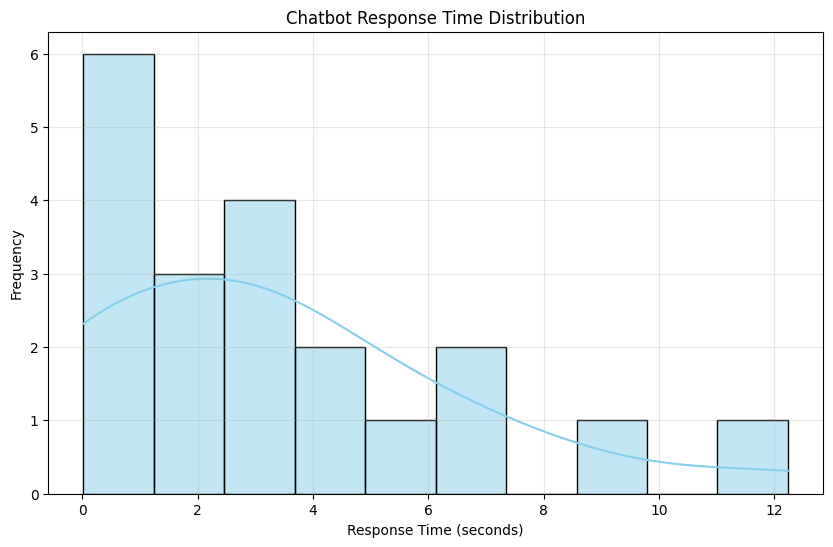

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is the dataframe from the previous script
plt.figure(figsize=(10, 6))
sns.histplot(df["Response Time (s)"], kde=True, bins=10, color="skyblue")
plt.title("Chatbot Response Time Distribution")
plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.savefig("response_time_dist.png")
plt.show()